# loading dataset

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

data_dir = Path("../data")

df = pd.read_csv(data_dir/"clean_dataset.csv")

df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## ensuring data type is right 

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   int64 
 2   self_employed             4269 non-null   int64 
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(11), object(1)
memory usage: 400.3+ KB


In [34]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

# dividing columns into numeric and binary to process data -> scaling

In [35]:
numeric_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 
                'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
binary_cols = ['education', 'self_employed']

# data into feature and label i.e x, y 

In [36]:
x = df.drop('loan_status', axis = 1)
y = df['loan_status']

y = y.map({"Approved":1, "Rejected":0})
y

0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

In [37]:
x.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

# splitting data using train test split

In [38]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# preprocessing using standardScaler

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler

StandardScaler()

# creating column transformer to perform process auto

In [42]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric_cols),
        ("binary", 'passthrough', binary_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['no_of_dependents', 'income_annum',
                                  'loan_amount', 'loan_term', 'cibil_score',
                                  'residential_assets_value',
                                  'commercial_assets_value',
                                  'luxury_assets_value', 'bank_asset_value']),
                                ('binary', 'passthrough',
                                 ['education', 'self_employed'])])

# loading model --> logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model

LogisticRegression()

# creating a pipeline -> contains columntransformer and model 

In [44]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value']),
                                                 ('binary', 'passthrough',
                                                  ['education',
                                                   'self_employed'])])),
                ('model', LogisticRegression())])

# fit data to train model 

In [45]:
model_pipeline.fit(x_train, y_train)
print("done")

done


In [49]:
y_pred = model_pipeline.predict(x_test)

# evaluation 

In [63]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_pred, y_test)
evaluation = classification_report(y_pred, y_test, target_names = ['Approved', 'Rejected'])

print(f"accuracy --> {(accuracy*100):.2f}% ")
print(evaluation)

accuracy --> 90.40% 
              precision    recall  f1-score   support

    Approved       0.86      0.88      0.87       312
    Rejected       0.93      0.92      0.92       542

    accuracy                           0.90       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.90      0.90       854



## Model Evaluation

- **Accuracy:** 90.40%

- **Classification Report:**

| Class | Precision | Recall | F1-Score | Support |
|---|---:|---:|---:|---:|
| Approved | 0.86 | 0.88 | 0.87 | 312 |
| Rejected | 0.93 | 0.92 | 0.92 | 542 |
| **Accuracy** | | | **0.90** | **854** |
| **Macro Avg** | **0.90** | **0.90** | **0.90** | **854** |
| **Weighted Avg** | **0.90** | **0.90** | **0.90** | **854** |

In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[274  44]
 [ 38 498]]


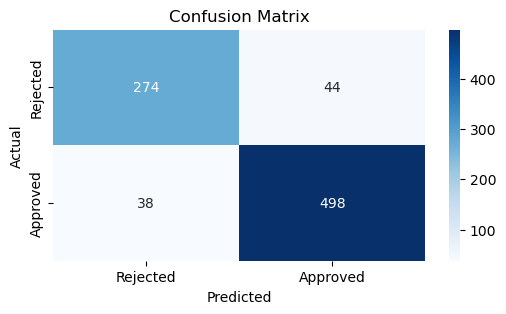

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (6, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()